In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.max_columns', None)

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv('bank.csv', sep=';')

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [3]:
df.shape

(4521, 17)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [5]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [6]:
# Convert target variable
df['conversion'] = df['y'].map({'yes': 1, 'no': 0})

# Check missing values
df.isnull().sum()

age           0
job           0
marital       0
education     0
default       0
balance       0
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
y             0
conversion    0
dtype: int64

In [7]:
total_leads = len(df)

contacted = df[df['contact'] != 'unknown']
engaged = df[df['duration'] > 0]
converted = df[df['conversion'] == 1]

funnel = pd.DataFrame({
    'Stage': ['Total Leads', 'Contacted', 'Engaged', 'Converted'],
    'Count': [total_leads, len(contacted), len(engaged), len(converted)]
})

funnel

,Stage,Count
0,Total Leads,4521
1,Contacted,3197
2,Engaged,4521
3,Converted,521


In [8]:
funnel['Conversion Rate (%)'] = funnel['Count'].pct_change() * 100
funnel

,Stage,Count,Conversion Rate (%)
0,Total Leads,4521,NaN
1,Contacted,3197,-29.285556
2,Engaged,4521,41.413825
3,Converted,521,-88.476001


In [9]:
funnel['Drop-off (%)'] = 100 - funnel['Conversion Rate (%)']
funnel

,Stage,Count,Conversion Rate (%),Drop-off (%)
0,Total Leads,4521,NaN,NaN
1,Contacted,3197,-29.285556,129.285556
2,Engaged,4521,41.413825,58.586175
3,Converted,521,-88.476001,188.476001


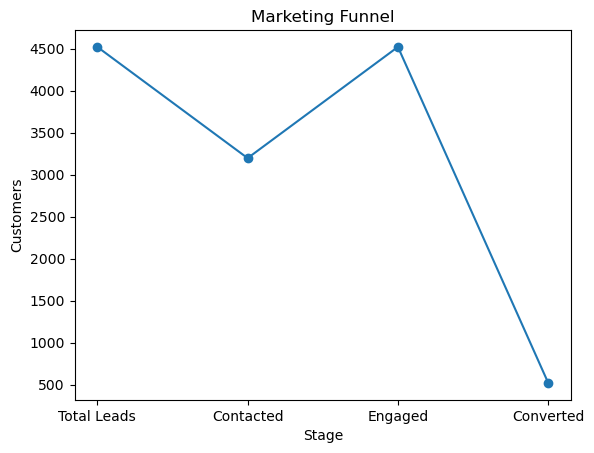

In [10]:
plt.figure()
plt.plot(funnel['Stage'], funnel['Count'], marker='o')
plt.title("Marketing Funnel")
plt.xlabel("Stage")
plt.ylabel("Customers")
plt.show()

In [11]:
channel_perf = df.groupby('contact').agg(
    total=('conversion', 'count'),
    conversions=('conversion', 'sum')
)

channel_perf['conversion_rate'] = (channel_perf['conversions'] / channel_perf['total']) * 100

channel_perf.sort_values(by='conversion_rate', ascending=False)

,total,conversions,conversion_rate
contact,,,
telephone,301,44,14.617940
cellular,2896,416,14.364641
unknown,1324,61,4.607251


In [12]:
campaign_perf = df.groupby('campaign').agg(
    total=('conversion', 'count'),
    conversions=('conversion', 'sum')
)

campaign_perf['conversion_rate'] = (campaign_perf['conversions'] / campaign_perf['total']) * 100

campaign_perf.head(10)

,total,conversions,conversion_rate
campaign,,,
1,1734,240,13.840830
2,1264,138,10.917722
3,558,57,10.215054
4,325,43,13.230769
5,167,9,5.389222
6,155,16,10.322581
7,75,6,8.000000
8,56,4,7.142857
9,30,2,6.666667


In [13]:
# Job-based conversion
job_perf = df.groupby('job')['conversion'].mean() * 100
job_perf.sort_values(ascending=False)

job
retired          23.478261
student          22.619048
unknown          18.421053
management       13.519092
housemaid        12.500000
admin.           12.133891
self-employed    10.928962
technician       10.807292
unemployed       10.156250
services          9.112710
entrepreneur      8.928571
blue-collar       7.293869
Name: conversion, dtype: float64

In [14]:
# Education-based conversion
edu_perf = df.groupby('education')['conversion'].mean() * 100
edu_perf.sort_values(ascending=False)

education
tertiary     14.296296
secondary    10.624458
unknown      10.160428
primary       9.439528
Name: conversion, dtype: float64

In [15]:
print("Overall Conversion Rate:", df['conversion'].mean() * 100)

print("\nTop Performing Channel:")
print(channel_perf.sort_values(by='conversion_rate', ascending=False).head(1))

print("\nBiggest Drop-off Stage:")
print(funnel.sort_values(by='Drop-off (%)', ascending=False).head(1))

Overall Conversion Rate: 11.523999115239992

Top Performing Channel:
           total  conversions  conversion_rate
contact                                       
telephone    301           44         14.61794

Biggest Drop-off Stage:
       Stage  Count  Conversion Rate (%)  Drop-off (%)
3  Converted    521           -88.476001    188.476001


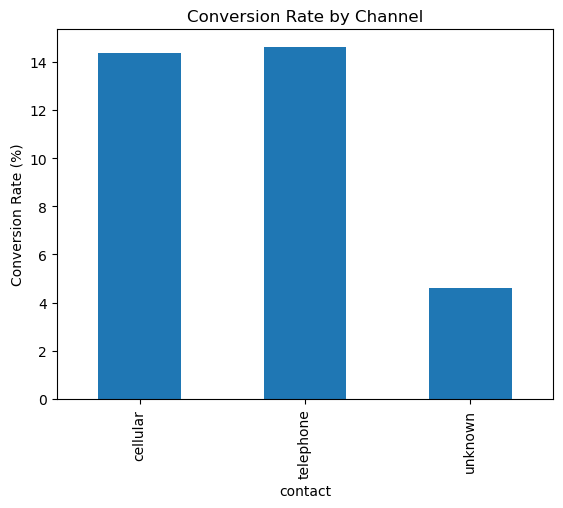

In [16]:
channel_perf['conversion_rate'].plot(kind='bar')
plt.title("Conversion Rate by Channel")
plt.ylabel("Conversion Rate (%)")
plt.show()